<a href="https://colab.research.google.com/github/dannynacker/LUCiO/blob/main/LUCIO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## LUCiO Colab Instructions

This notebook contains two Lucia/RX1-compatible `.lscf` sourcecode generators:

```text
LUCiO          audio-driven sourcecode generation
LUCiO-Composer typed/manual sourcecode composition
```

Both modes use the same validated GUI-authored dynamic-duty template:

```text
d_spcwkdc1020904022_various.lscf
```

Upload this template first. The template is used as a validated Lucia header/row-grammar carrier. LUCiO preserves the template header and internal Lucia identity, replaces the sourcecode rows with newly generated stimulation parameters, and recomputes the final checksum.

### LUCiO: audio-driven mode

LUCiO converts an uploaded audio file into a row-based Lucia sourcecode. For each control window, the notebook estimates audio-derived frequency, luminance, and duty-cycle values, then writes these values across OSC1–OSC4.

Audio-mode outputs:

```text
user/sourcecodes/d_<audio_name>_various.lscf
debug/<audio_name>_lucio_debug.csv
plots/<audio_name>_lucio_sequence_plot.png
plots/<audio_name>_lucio_sequence_plot.pdf
```

### LUCiO-Composer: scripted/manual mode

LUCiO-Composer does not use audio. Instead, you define a timed sequence directly in the notebook by typing step durations and OSC1–OSC4 frequency, luminance, and duty-cycle values. Values can be fixed or written as `[start, end]` ramps. Ramps are expanded by the notebook into discrete Lucia rows; Lucia itself receives one target state per row.

Composer-mode outputs:

```text
user/sourcecodes/d_<sequence_name>_various.lscf
debug/<sequence_name>_lucio_composer_debug.csv
plots/<sequence_name>_lucio_composer_plot.png
plots/<sequence_name>_lucio_composer_plot.pdf
```

### Loading generated files in Lucia

Copy one generated `.lscf` at a time into:

```text
USB Lucia/user/sourcecodes/
```

Then load it in Lucia via:

```text
Session editor → D → various → spcwkdc1020904022
```

The generated file will initially appear under the template’s internal Lucia name, `spcwkdc1020904022`. This is expected because both LUCiO and LUCiO-Composer preserve the validated dynamic-duty template header. After loading, save/resave the file in Lucia as a normal session or session configuration with the desired final name.

### Current validation status

Current validated features:

```text
Dynamic frequency
Dynamic luminance
Dynamic duty cycle
Independent OSC1–OSC4 values in Composer mode
All-four-oscillator output
1-s row-based control
Viewable/playable Lucia sourcecodes
Resavable Lucia sessions/session configurations
```

Current limitations:

```text
Generated files inherit the template’s internal Lucia display name
One-file-at-a-time loading is recommended
Lucia rows store discrete target states, not native start/end ramps
Composer ramps are pre-expanded into 1-s rows before export
No halogen/wash-light layer yet
```


LUCIO-D sourcecode export

Step 1: upload the validated dynamic-duty Lucia template:
  d_spcwkdc1020904022_various.lscf



Saving d_spcwkdc1020904022_various.lscf to d_spcwkdc1020904022_various (3).lscf
Template loaded
  File: d_spcwkdc1020904022_various (3).lscf
  Lucia display name: spcwkdc1020904022
  Template rows: 461
  First-row OSC duties: [10, 10, 10, 10]

Step 2: upload one or more audio files
Supported: wav, mp3, flac, m4a, ogg, aiff



Saving DJS_space_walk.mp3 to DJS_space_walk (1).mp3
------------------------------------------------------------
Processing: DJS_space_walk (1).mp3
  Duration: 460.30 s
  Output file: d_djsspacewalk1_various.lscf
  Lucia display name: spcwkdc1020904022
  Control step: 1.00 s


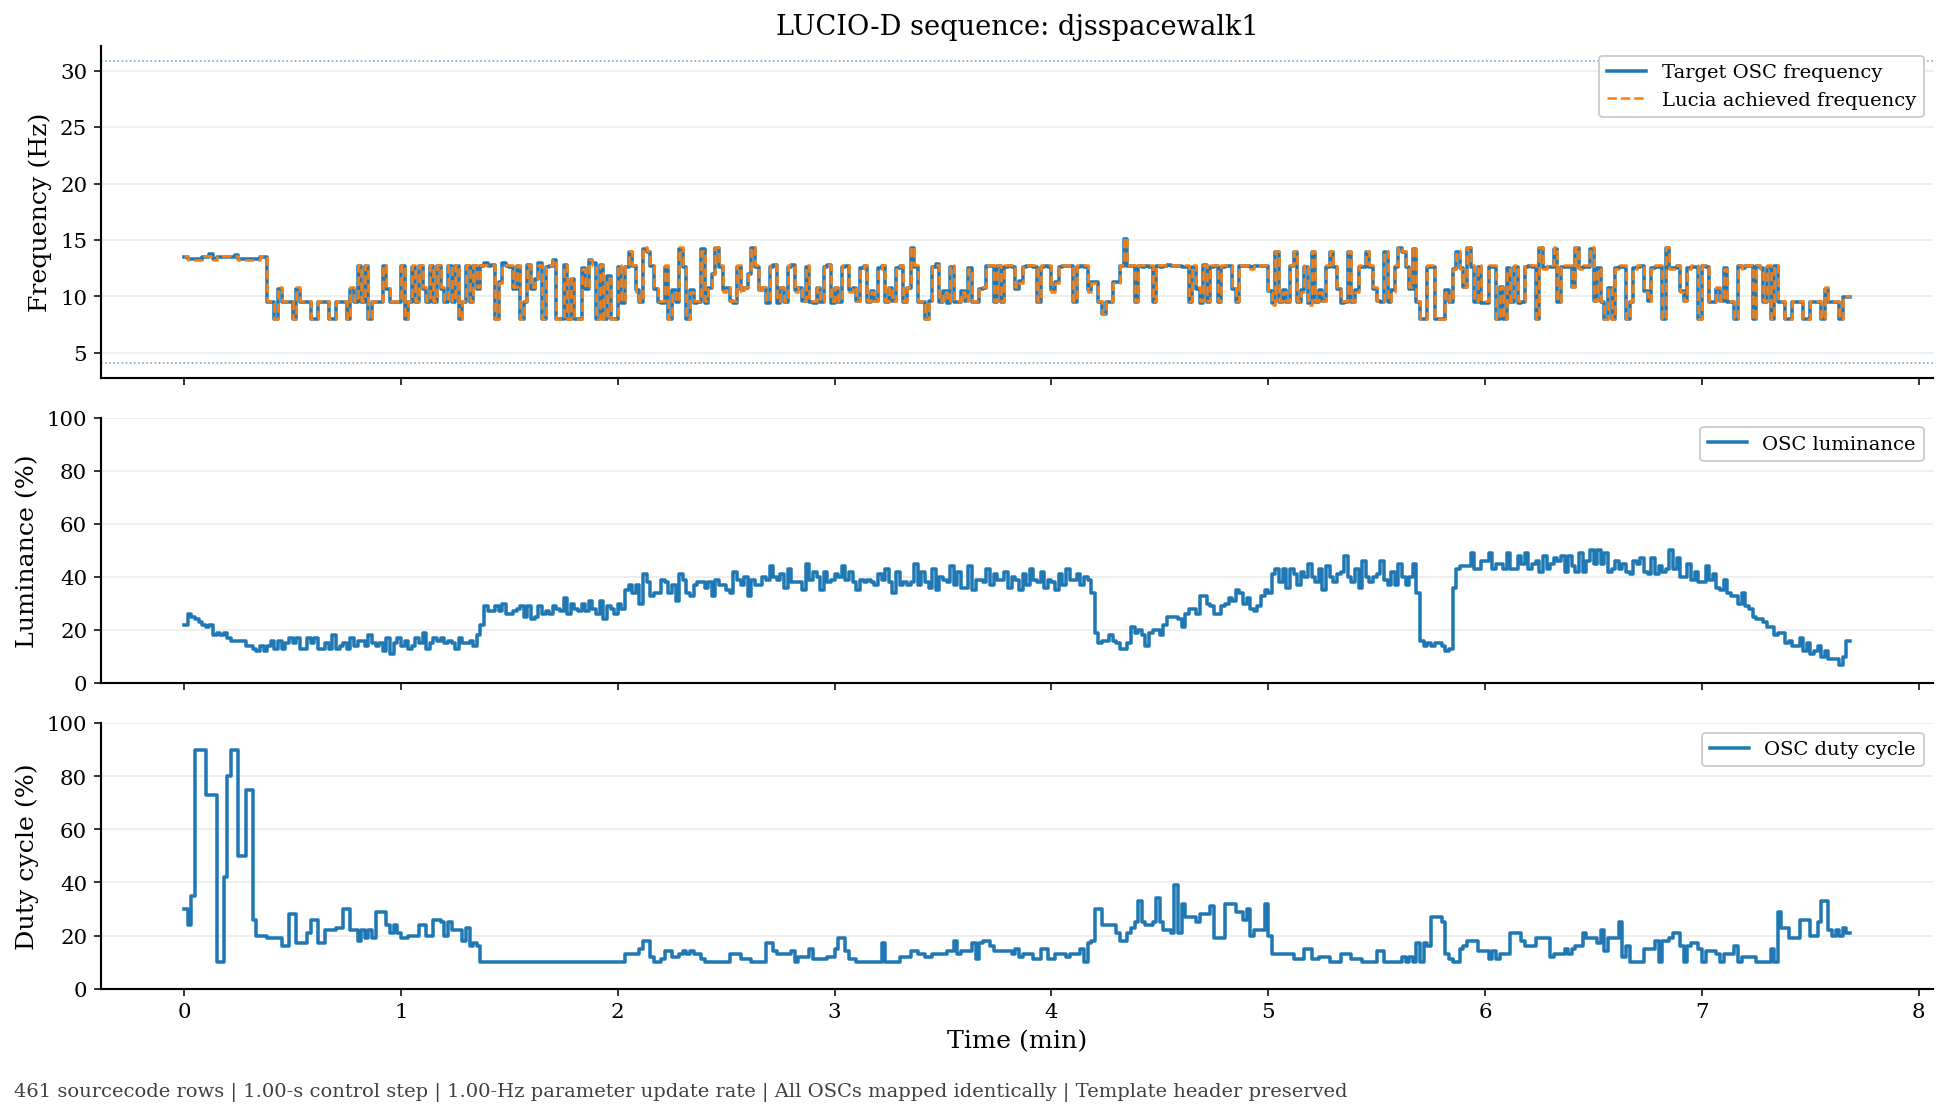

  Rows written: 461
  Approx duration: 461.00 s
  Achieved frequency: 8.00–15.20 Hz
  Luminance: 7–50
  Duty cycle: 10–90
  Checksum valid: True

LUCIO-D export complete
Copy one generated .lscf file at a time into:
  USB Lucia/user/sourcecodes/

Then load in Lucia:
  Session editor -> D -> various -> spcwkdc1020904022

The output filename is audio-specific, but the initial Lucia display
name is inherited from the validated template. After loading, resave
the sourcecode/session in Lucia under the desired final name.

Export settings:
  Control step: 1.00 s
  Parameter update rate: 1.00 Hz
  Duty method: occupancy
  Duty bounds: 10–90
  Luminance bounds: 5–50


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# LUCiO
# Lucia Unified Control Interface for OctAVEs
# Dynamic-duty sourcecode export for Lucia/RX1
# ============================================================
#
# Purpose
# -------
# Converts an audio file into a Lucia/RX1-compatible .lscf sourcecode.
# The generated sourcecode contains one row per control window and maps
# audio-derived features to:
#
#   - oscillator frequency
#   - oscillator luminance
#   - oscillator duty cycle
#
# Validated template
# ------------------
# Use the GUI-authored dynamic-duty template:
#
#   d_spcwkdc1020904022_various.lscf
#
# This template's header/internal identity is preserved. Therefore, inside
# Lucia, generated sourcecodes will initially appear under the template's
# internal display name:
#
#   spcwkdc1020904022
#
# After loading in Lucia, the sourcecode can be saved/resaved as a normal
# session or session configuration with the desired final name.
#
# Output
# ------
#   user/sourcecodes/d_<audio_name>_various.lscf
#   debug/<audio_name>_lucio_debug.csv
#   plots/<audio_name>_lucio_sequence_plot.png
#   plots/<audio_name>_lucio_sequence_plot.pdf
#
# Recommended use
# ---------------
# Copy one generated .lscf at a time into:
#
#   USB Lucia/user/sourcecodes/
#
# Then load in Lucia:
#
#   Session editor -> D -> various -> spcwkdc1020904022
#
# ============================================================

!pip -q install librosa soundfile numpy pandas scipy matplotlib

from __future__ import annotations

import math
import re
import struct
import zipfile
from dataclasses import dataclass
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from scipy.signal import hilbert

from google.colab import files


# ============================================================
# CONFIGURATION
# ============================================================

@dataclass(frozen=True)
class LucioConfig:
    # Row/control timing
    control_step_seconds: float = 1.0
    displayed_seconds_tenths: int = 10
    loops_per_row: int = 1

    # Luminance mapping
    luminance_min: int = 5
    luminance_max: int = 50

    # Duty-cycle mapping: "occupancy", "mean_envelope", or "fixed"
    duty_method: str = "occupancy"
    duty_fixed: int = 50
    duty_min: int = 10
    duty_max: int = 90
    duty_fallback: int = 50
    duty_invert: bool = False
    duty_occupancy_threshold: float = 0.35

    # Optional duty shaping
    duty_smooth_rows: int | None = 3
    duty_quantize_step: int | None = 1
    duty_max_row_change: int | None = None

    # Audio spectral extraction
    audio_band_low_hz: float = 40.0
    audio_band_high_hz: float = 6000.0

    # SLS frequency range
    sls_min_hz: float = 4.12
    sls_max_hz: float = 30.87
    sls_center_hz: float = 11.56

    # Plotting
    make_sequence_plot: bool = True
    time_units: str = "min"


CFG = LucioConfig()


# ============================================================
# LUCIA/RX1 BINARY CONSTANTS
# ============================================================

HEADER_LEN = 132
ROW_LEN = 56
CHECKSUM_LEN = 1

NAME_FIELD_OFFSET = 24
NAME_FIELD_LEN = 56

DUTY_OFFSETS = [3, 11, 19, 27]


# ============================================================
# LOW-LEVEL LUCIA HELPERS
# ============================================================

def lucia_xor_checksum(data_without_checksum: bytes) -> int:
    checksum = 0
    for byte in data_without_checksum:
        checksum ^= byte
    return checksum


def finalize_lucia_file(buffer: bytearray) -> bytearray:
    buffer = bytearray(buffer)
    buffer[-1] = lucia_xor_checksum(buffer[:-1])
    return buffer


def verify_lucia_checksum(data: bytes) -> bool:
    return data[-1] == lucia_xor_checksum(data[:-1])


def read_internal_name(data: bytes) -> str:
    raw = bytes(data[NAME_FIELD_OFFSET:NAME_FIELD_OFFSET + NAME_FIELD_LEN])
    raw = raw.split(b"\x00", 1)[0]
    return raw.decode("ascii", errors="replace")


def sanitize_filename_stem(name: str, max_len: int = 18) -> str:
    stem = Path(str(name)).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "", stem)

    if not stem:
        stem = "lucio"

    if stem[0].isdigit():
        stem = "l" + stem

    return stem[:max_len]


def parse_lucia_rows(data: bytes) -> list[bytearray]:
    n_rows = (len(data) - HEADER_LEN - CHECKSUM_LEN) // ROW_LEN
    expected_len = HEADER_LEN + n_rows * ROW_LEN + CHECKSUM_LEN

    if len(data) != expected_len:
        raise ValueError(
            f"Invalid .lscf size: {len(data)} bytes. "
            f"Expected 132 + 56*N + 1 bytes."
        )

    return [
        bytearray(data[HEADER_LEN + i * ROW_LEN:HEADER_LEN + (i + 1) * ROW_LEN])
        for i in range(n_rows)
    ]


def main_cycle_seconds_from_row(row: bytes) -> float:
    stored = struct.unpack("<H", bytes(row[44:46]))[0]
    if stored <= 0:
        return 2.5
    return 2500.0 / float(stored)


def clamp_byte(value: float) -> int:
    return int(np.clip(round(float(value)), 0, 255))


def cycles_from_hz(freq_hz: float, main_cycle_seconds: float) -> int:
    cycles = int(round(float(freq_hz) * float(main_cycle_seconds)))
    return int(np.clip(cycles, 1, 255))


# ============================================================
# AUDIO FEATURE EXTRACTION
# ============================================================

def octave_candidates(freq_hz: float, max_pow: int = 14) -> list[float]:
    if freq_hz <= 0:
        return []
    return [float(freq_hz) * (2.0 ** k) for k in range(-max_pow, max_pow + 1)]


def fold_frequency_to_sls_range(freq_hz: float, cfg: LucioConfig = CFG) -> float:
    if freq_hz <= 0:
        return cfg.sls_center_hz

    candidates = [
        f for f in octave_candidates(freq_hz)
        if cfg.sls_min_hz <= f <= cfg.sls_max_hz
    ]

    if candidates:
        candidates.sort(key=lambda f: abs(f - cfg.sls_center_hz))
        return float(candidates[0])

    folded = float(freq_hz)

    for _ in range(64):
        if folded < cfg.sls_min_hz:
            folded *= 2.0
        elif folded > cfg.sls_max_hz:
            folded /= 2.0
        else:
            break

    return float(np.clip(folded, cfg.sls_min_hz, cfg.sls_max_hz))


def next_power_of_two(n: int) -> int:
    return 1 << (int(n) - 1).bit_length()


def dominant_frequency_for_segment(
    segment: np.ndarray,
    sr: int,
    cfg: LucioConfig = CFG
) -> float:
    segment = np.asarray(segment, dtype=np.float32)

    if len(segment) < 16 or np.max(np.abs(segment)) <= 0:
        return cfg.sls_center_hz

    window = np.hanning(len(segment)).astype(np.float32)
    n_fft = max(4096, next_power_of_two(len(segment)))

    spectrum = np.abs(np.fft.rfft(segment * window, n=n_fft))
    freqs = np.fft.rfftfreq(n_fft, d=1.0 / sr)

    band = (freqs >= cfg.audio_band_low_hz) & (freqs <= cfg.audio_band_high_hz)

    if not np.any(band):
        return cfg.sls_center_hz

    band_spectrum = spectrum[band]
    band_freqs = freqs[band]

    if len(band_spectrum) == 0 or np.max(band_spectrum) <= 0:
        return cfg.sls_center_hz

    return float(band_freqs[int(np.argmax(band_spectrum))])


def raw_duty_for_segment(segment: np.ndarray, cfg: LucioConfig = CFG) -> float:
    method = cfg.duty_method.lower().strip()

    if method == "fixed":
        return float(cfg.duty_fixed)

    segment = np.asarray(segment, dtype=np.float32)

    if len(segment) < 16 or np.max(np.abs(segment)) <= 0:
        return float(cfg.duty_fallback)

    envelope = np.abs(hilbert(segment.astype(np.float64)))
    peak = float(np.max(envelope))

    if peak <= 1e-12:
        return float(cfg.duty_fallback)

    envelope_norm = envelope / peak

    if method == "occupancy":
        duty = 100.0 * float(np.mean(envelope_norm > cfg.duty_occupancy_threshold))
    elif method == "mean_envelope":
        duty = 100.0 * float(np.mean(envelope_norm))
    else:
        raise ValueError(
            f"Unknown duty method: {cfg.duty_method}. "
            "Use 'occupancy', 'mean_envelope', or 'fixed'."
        )

    if cfg.duty_invert:
        duty = 100.0 - duty

    return float(duty)


def shape_duty_series(
    duty_values: np.ndarray,
    cfg: LucioConfig = CFG
) -> np.ndarray:
    duty = pd.Series(np.asarray(duty_values, dtype=float))
    duty = duty.clip(cfg.duty_min, cfg.duty_max)

    if cfg.duty_smooth_rows is not None and cfg.duty_smooth_rows > 1:
        duty = duty.rolling(
            window=int(cfg.duty_smooth_rows),
            center=True,
            min_periods=1
        ).median()

    duty_array = duty.to_numpy(dtype=float)

    if cfg.duty_max_row_change is not None and cfg.duty_max_row_change > 0:
        shaped = np.zeros_like(duty_array)
        shaped[0] = duty_array[0]

        for i in range(1, len(duty_array)):
            delta = duty_array[i] - shaped[i - 1]
            delta = np.clip(delta, -cfg.duty_max_row_change, cfg.duty_max_row_change)
            shaped[i] = shaped[i - 1] + delta

        duty_array = shaped

    if cfg.duty_quantize_step is not None and cfg.duty_quantize_step > 0:
        duty_array = np.round(duty_array / cfg.duty_quantize_step) * cfg.duty_quantize_step

    duty_array = np.clip(
        np.round(duty_array),
        cfg.duty_min,
        cfg.duty_max
    ).astype(int)

    return duty_array


def extract_audio_control_table(
    audio_path: str,
    cfg: LucioConfig = CFG
) -> pd.DataFrame:
    y, sr = librosa.load(audio_path, sr=None, mono=True)
    y = y.astype(np.float32)

    step_samples = int(round(sr * cfg.control_step_seconds))

    if step_samples <= 0:
        raise ValueError("control_step_seconds must be positive.")

    n_steps = int(math.ceil(len(y) / step_samples))
    rows = []

    for i in range(n_steps):
        start = i * step_samples
        stop = min(len(y), start + step_samples)
        segment = y[start:stop]

        if len(segment) == 0:
            continue

        raw_freq = dominant_frequency_for_segment(segment, sr, cfg)
        sls_freq = fold_frequency_to_sls_range(raw_freq, cfg)

        rms = float(np.sqrt(np.mean(segment ** 2))) if len(segment) else 0.0
        duty_raw = raw_duty_for_segment(segment, cfg)

        rows.append({
            "row": i + 1,
            "time_sec": i * cfg.control_step_seconds,
            "raw_freq_hz": raw_freq,
            "sls_freq_hz": sls_freq,
            "rms": rms,
            "duty_raw": duty_raw
        })

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError(f"No control rows extracted from {audio_path}")

    rms_max = float(df["rms"].max())
    if rms_max <= 0:
        rms_max = 1.0

    df["amp_norm"] = df["rms"] / rms_max
    df["luminance"] = (
        cfg.luminance_min
        + df["amp_norm"] * (cfg.luminance_max - cfg.luminance_min)
    ).round().clip(cfg.luminance_min, cfg.luminance_max).astype(int)

    df["duty"] = shape_duty_series(df["duty_raw"].values, cfg)

    return df


# ============================================================
# LUCIA ROW GENERATION
# ============================================================

def patch_lucia_row(
    template_row: bytes,
    control_row: pd.Series,
    cfg: LucioConfig = CFG
) -> tuple[bytearray, dict]:
    row = bytearray(template_row)

    main_cycle_seconds = main_cycle_seconds_from_row(row)

    freq_hz = float(control_row["sls_freq_hz"])
    luminance = int(control_row["luminance"])
    duty = int(control_row["duty"])
    cycles = cycles_from_hz(freq_hz, main_cycle_seconds)

    for osc in range(4):
        base = osc * 8

        row[base + 0] = 1
        row[base + 1] = 1
        row[base + 2] = 100
        row[base + 3] = clamp_byte(duty)
        row[base + 4] = clamp_byte(cycles)
        row[base + 5] = 0
        row[base + 6] = 1
        row[base + 7] = 0

    for osc in range(4):
        row[32 + osc] = clamp_byte(luminance)
        row[36 + osc] = 1

    # Validated D/various halogen-off grammar.
    row[40:44] = bytes([0x00, 0x01, 0x00, 0x14])

    # Sourcecode row timing/control convention.
    row[46] = 1
    row[47] = 1
    row[48] = clamp_byte(cfg.displayed_seconds_tenths)
    row[49] = 0
    row[50] = 0
    row[51] = 0

    row[52:56] = struct.pack("<I", int(cfg.loops_per_row))

    debug = {
        "main_cycle_seconds": main_cycle_seconds,
        "displayed_row_seconds": row[48] / 10.0,
        "cycles": cycles,
        "achieved_freq_hz": cycles / main_cycle_seconds,
        "row_40_56_hex": row[40:56].hex(" ")
    }

    return row, debug


def build_lucia_sourcecode(
    template_data: bytes,
    control_df: pd.DataFrame,
    output_path: str,
    cfg: LucioConfig = CFG
) -> tuple[str, pd.DataFrame]:
    template_data = bytearray(template_data)
    template_rows = parse_lucia_rows(template_data)
    template_row = template_rows[0]

    out = bytearray()
    out.extend(template_data[:HEADER_LEN])

    debug_rows = []

    for _, control_row in control_df.iterrows():
        patched_row, row_debug = patch_lucia_row(template_row, control_row, cfg)
        out.extend(patched_row)

        debug_row = dict(control_row)
        debug_row.update(row_debug)
        debug_rows.append(debug_row)

    out.extend(b"\x00")
    out = finalize_lucia_file(out)

    if not verify_lucia_checksum(out):
        raise RuntimeError("Final Lucia XOR checksum failed.")

    Path(output_path).write_bytes(out)

    return output_path, pd.DataFrame(debug_rows)


# ============================================================
# SEQUENCE PLOT
# ============================================================

def make_sequence_plot(
    debug_df: pd.DataFrame,
    stem: str,
    cfg: LucioConfig = CFG
) -> tuple[str, str]:
    time_sec = debug_df["time_sec"].to_numpy(dtype=float)

    if cfg.time_units.lower().startswith("min"):
        t = time_sec / 60.0
        final_t = (time_sec[-1] + cfg.control_step_seconds) / 60.0
        x_label = "Time (min)"
    else:
        t = time_sec
        final_t = time_sec[-1] + cfg.control_step_seconds
        x_label = "Time (s)"

    t_step = np.append(t, final_t)

    def step_values(values):
        values = np.asarray(values, dtype=float)
        return np.append(values, values[-1])

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Palatino", "Palatino Linotype", "DejaVu Serif"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 1.1,
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 10,
        "figure.dpi": 140,
    })

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(14, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [1.25, 1.0, 1.0]}
    )

    ax_freq, ax_lum, ax_duty = axes

    ax_freq.step(
        t_step,
        step_values(debug_df["sls_freq_hz"]),
        where="post",
        linewidth=1.8,
        label="Target OSC frequency"
    )
    ax_freq.step(
        t_step,
        step_values(debug_df["achieved_freq_hz"]),
        where="post",
        linewidth=1.3,
        linestyle="--",
        label="Lucia achieved frequency"
    )
    ax_freq.axhline(cfg.sls_min_hz, linewidth=0.8, linestyle=":", alpha=0.7)
    ax_freq.axhline(cfg.sls_max_hz, linewidth=0.8, linestyle=":", alpha=0.7)
    ax_freq.set_ylabel("Frequency (Hz)")
    ax_freq.set_title(f"LUCIO-D sequence: {stem}")
    ax_freq.legend(loc="upper right", frameon=True, framealpha=0.95)
    ax_freq.grid(axis="y", alpha=0.25)

    ax_lum.step(
        t_step,
        step_values(debug_df["luminance"]),
        where="post",
        linewidth=1.8,
        label="OSC luminance"
    )
    ax_lum.set_ylabel("Luminance (%)")
    ax_lum.set_ylim(0, max(100, float(debug_df["luminance"].max()) * 1.1))
    ax_lum.legend(loc="upper right", frameon=True, framealpha=0.95)
    ax_lum.grid(axis="y", alpha=0.25)

    ax_duty.step(
        t_step,
        step_values(debug_df["duty"]),
        where="post",
        linewidth=1.8,
        label="OSC duty cycle"
    )
    ax_duty.set_ylabel("Duty cycle (%)")
    ax_duty.set_ylim(0, 100)
    ax_duty.set_xlabel(x_label)
    ax_duty.legend(loc="upper right", frameon=True, framealpha=0.95)
    ax_duty.grid(axis="y", alpha=0.25)

    footer = (
        f"{len(debug_df)} sourcecode rows | "
        f"{cfg.control_step_seconds:.2f}-s control step | "
        f"{1 / cfg.control_step_seconds:.2f}-Hz parameter update rate | "
        "All OSCs mapped identically | "
        "Template header preserved"
    )

    fig.text(0.01, 0.01, footer, ha="left", va="bottom", fontsize=10, alpha=0.75)
    plt.tight_layout(rect=[0, 0.035, 1, 1])

    png_path = f"/content/{stem}_lucio_sequence_plot.png"
    pdf_path = f"/content/{stem}_lucio_sequence_plot.pdf"

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    return png_path, pdf_path


# ============================================================
# COLAB RUNNER
# ============================================================

print("LUCIO-D sourcecode export")
print("")
print("Step 1: upload the validated dynamic-duty Lucia template:")
print("  d_spcwkdc1020904022_various.lscf")
print("")

template_upload = files.upload()

template_filename = next(iter(template_upload.keys()))
template_data = bytearray(Path(template_filename).read_bytes())
template_rows = parse_lucia_rows(template_data)

if not verify_lucia_checksum(template_data):
    raise RuntimeError("Template checksum is invalid.")

template_display_name = read_internal_name(template_data)

print("Template loaded")
print(f"  File: {template_filename}")
print(f"  Lucia display name: {template_display_name}")
print(f"  Template rows: {len(template_rows)}")
print(f"  First-row OSC duties: {[template_rows[0][off] for off in DUTY_OFFSETS]}")
print("")

print("Step 2: upload one or more audio files")
print("Supported: wav, mp3, flac, m4a, ogg, aiff")
print("")

audio_upload = files.upload()

audio_exts = {".wav", ".mp3", ".flac", ".m4a", ".ogg", ".aiff", ".aif"}
audio_paths = [
    Path(filename)
    for filename in audio_upload.keys()
    if Path(filename).suffix.lower() in audio_exts
]

if not audio_paths:
    raise ValueError("No supported audio files were uploaded.")

outputs = []

for audio_path in audio_paths:
    audio_stem = sanitize_filename_stem(audio_path.stem, max_len=18)

    lscf_path = f"/content/d_{audio_stem}_various.lscf"
    debug_path = f"/content/{audio_stem}_lucio_debug.csv"

    info = sf.info(str(audio_path))
    duration_sec = info.frames / info.samplerate

    print("------------------------------------------------------------")
    print(f"Processing: {audio_path.name}")
    print(f"  Duration: {duration_sec:.2f} s")
    print(f"  Output file: {Path(lscf_path).name}")
    print(f"  Lucia display name: {template_display_name}")
    print(f"  Control step: {CFG.control_step_seconds:.2f} s")

    control_df = extract_audio_control_table(str(audio_path), CFG)

    _, debug_df = build_lucia_sourcecode(
        template_data=template_data,
        control_df=control_df,
        output_path=lscf_path,
        cfg=CFG
    )

    debug_df.to_csv(debug_path, index=False)

    plot_paths = []
    if CFG.make_sequence_plot:
        plot_paths = list(make_sequence_plot(debug_df, audio_stem, CFG))

    print(f"  Rows written: {len(debug_df)}")
    print(f"  Approx duration: {len(debug_df) * CFG.control_step_seconds:.2f} s")
    print(
        f"  Achieved frequency: "
        f"{debug_df['achieved_freq_hz'].min():.2f}–"
        f"{debug_df['achieved_freq_hz'].max():.2f} Hz"
    )
    print(
        f"  Luminance: "
        f"{int(debug_df['luminance'].min())}–"
        f"{int(debug_df['luminance'].max())}"
    )
    print(
        f"  Duty cycle: "
        f"{int(debug_df['duty'].min())}–"
        f"{int(debug_df['duty'].max())}"
    )
    print(f"  Checksum valid: {verify_lucia_checksum(Path(lscf_path).read_bytes())}")
    print("")

    outputs.append((lscf_path, debug_path, plot_paths))

zip_path = "/content/lucio_d_exports.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for lscf_path, debug_path, plot_paths in outputs:
        z.write(lscf_path, arcname=f"user/sourcecodes/{Path(lscf_path).name}")
        z.write(debug_path, arcname=f"debug/{Path(debug_path).name}")

        for plot_path in plot_paths:
            z.write(plot_path, arcname=f"plots/{Path(plot_path).name}")

print("============================================================")
print("LUCIO-D export complete")
print("============================================================")
print("Copy one generated .lscf file at a time into:")
print("  USB Lucia/user/sourcecodes/")
print("")
print("Then load in Lucia:")
print(f"  Session editor -> D -> various -> {template_display_name}")
print("")
print("The output filename is audio-specific, but the initial Lucia display")
print("name is inherited from the validated template. After loading, resave")
print("the sourcecode/session in Lucia under the desired final name.")
print("")
print("Export settings:")
print(f"  Control step: {CFG.control_step_seconds:.2f} s")
print(f"  Parameter update rate: {1 / CFG.control_step_seconds:.2f} Hz")
print(f"  Duty method: {CFG.duty_method}")
print(f"  Duty bounds: {CFG.duty_min}–{CFG.duty_max}")
print(f"  Luminance bounds: {CFG.luminance_min}–{CFG.luminance_max}")
print("============================================================")

files.download(zip_path)

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 324, in run
    session = self.get_default_session(options)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/index_command.py", line 71, in get_default_session
    self._session = self.enter_context(self._build_session(options))
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/index_command.py", line 100, in _build_session
    session = PipSession(
              ^^^^^^^^^

Saving d_spcwkdc1020904022_various.lscf to d_spcwkdc1020904022_various.lscf
Template loaded
  File: d_spcwkdc1020904022_various.lscf
  Lucia display name: spcwkdc1020904022
  Template rows: 461
  First-row OSC duties: [10, 10, 10, 10]

Expanding scripted sequence


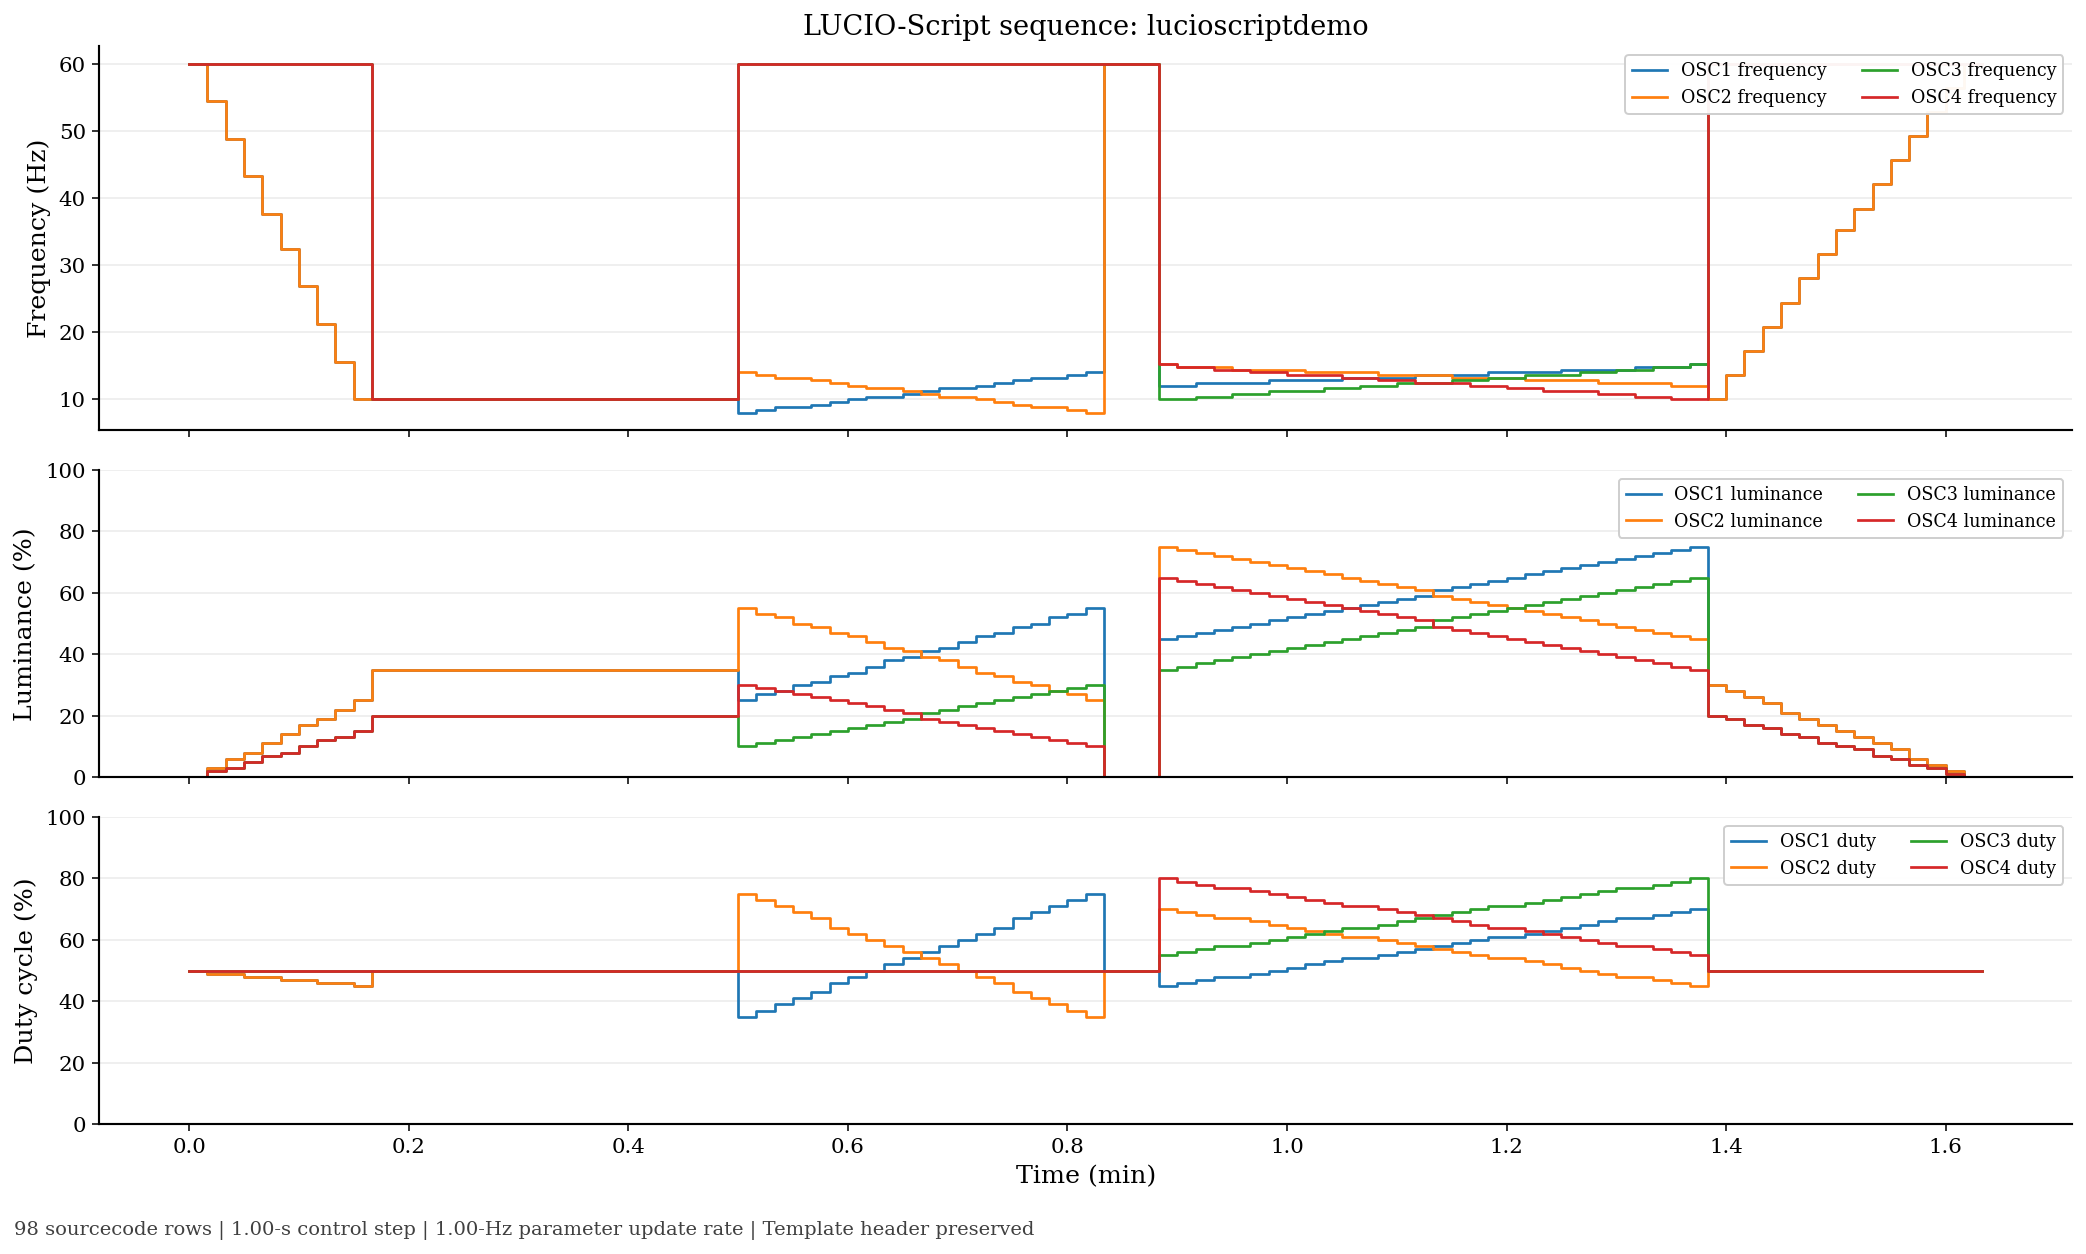

Export summary
  Sequence name: lucioscriptdemo
  Output file: d_lucioscriptdemo_various.lscf
  Lucia display name: spcwkdc1020904022
  Rows written: 98
  Approx exported duration: 98.00 s
  Checksum valid: True

  OSC1: freq 8.00–60.00 Hz | lum 0–75 | duty 35–75
  OSC2: freq 8.00–60.00 Hz | lum 0–75 | duty 35–75
  OSC3: freq 10.00–60.00 Hz | lum 0–65 | duty 50–80
  OSC4: freq 10.00–60.00 Hz | lum 0–65 | duty 50–80

LUCIO-Script export complete
Copy the generated .lscf file into:
  USB Lucia/user/sourcecodes/

Then load in Lucia:
  Session editor -> D -> various -> spcwkdc1020904022

The output filename is sequence-specific, but the initial Lucia display
name is inherited from the validated template. After loading, resave
the sourcecode/session in Lucia under the desired final name.

Export settings:
  Control step: 1.00 s
  Parameter update rate: 1.00 Hz
  Row duration byte: 10


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================================
# LUCiO-Composer
# Lucia Unified Control Interface for OctAVEs
# Scripted sourcecode export for Lucia/RX1
# ============================================================
#
# Purpose
# -------
# Generates a Lucia/RX1-compatible .lscf sourcecode from a hand-authored
# sequence rather than from audio.
#
# Each authored step can specify OSC1-OSC4 frequency, luminance, and duty.
# Values may be fixed scalars or [start, end] pairs. [start, end] pairs
# are expanded by LUCiO into one discrete Lucia row per control step.
#
# Validated template
# ------------------
# Upload the GUI-authored dynamic-duty template:
#
#   d_spcwkdc1020904022_various.lscf
#
# This template's header/internal identity is preserved. Therefore, inside
# Lucia, generated sourcecodes will initially appear under the template's
# internal display name:
#
#   spcwkdc1020904022
#
# After loading in Lucia, save/resave as a normal session/session config
# with the desired final name.
#
# Output
# ------
#   user/sourcecodes/d_<sequence_name>_various.lscf
#   debug/<sequence_name>_lucio_script_debug.csv
#   plots/<sequence_name>_lucio_script_plot.png
#   plots/<sequence_name>_lucio_script_plot.pdf
#
# Recommended use
# ---------------
# Copy one generated .lscf at a time into:
#
#   USB Lucia/user/sourcecodes/
#
# Then load in Lucia:
#
#   Session editor -> D -> various -> spcwkdc1020904022
#
# ============================================================

!pip -q install numpy pandas matplotlib

from __future__ import annotations

import math
import re
import struct
import zipfile
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from google.colab import files


# ============================================================
# CONFIGURATION
# ============================================================

@dataclass(frozen=True)
class LucioScriptConfig:
    # Lucia export resolution.
    # 1.0 s is the validated default.
    control_step_seconds: float = 1.0
    displayed_seconds_tenths: int = 10
    loops_per_row: int = 1

    # Parameter bounds.
    freq_min_hz: float = 0.0
    freq_max_hz: float = 60.0
    luminance_min: int = 0
    luminance_max: int = 100
    duty_min: int = 10
    duty_max: int = 90

    # Defaults for missing oscillator fields.
    default_freq_hz: float = 60.0
    default_luminance: int = 0
    default_duty: int = 50

    # Keep OSC blocks structurally active and use luminance=0 for off states.
    # This matches the most stable LUCIO-D behaviour.
    keep_all_oscillators_active: bool = True

    # Plotting.
    make_sequence_plot: bool = True
    time_units: str = "min"


CFG = LucioScriptConfig()


# ============================================================
# SCRIPTED SEQUENCE
# ============================================================
#
# Authoring rules:
#
# 1. Each step needs a duration in seconds.
#
# 2. Each oscillator can be specified as "osc1", "osc2", "osc3", "osc4".
#
# 3. Frequency, luminance, and duty may be:
#      - scalar: fixed for the step
#      - [start, end]: linearly expanded across exported rows
#
# 4. Missing oscillator fields fall back to:
#      freq = 60 Hz, luminance = 0, duty = 50
#
# 5. This does NOT mean Lucia stores native start/end values.
#    LUCiO-Composer expands ramps into one discrete target state per row.
#
# Convenience:
#   - Use osc(freq, lum, duty) for fixed values.
#   - Use ramp(freq=[a,b], lum=[a,b], duty=[a,b]) for ramps.
#   - Use off() for a dark/off oscillator.
#
# ============================================================

SEQUENCE_NAME = "luciocomposerdemo"


def osc(freq=10, lum=40, duty=50):
    return {"freq": freq, "lum": lum, "duty": duty}


def ramp(freq=10, lum=40, duty=50):
    return {"freq": freq, "lum": lum, "duty": duty}


def off():
    return {"freq": 60, "lum": 0, "duty": 50}


STEPS = [
    {
        "label": "soft_warmup",
        "duration": 10,
        "osc1": ramp(freq=[60, 10], lum=[0, 25], duty=[50, 45]),
        "osc2": ramp(freq=[60, 10], lum=[0, 25], duty=[50, 45]),
        "osc3": ramp(freq=[60, 60], lum=[0, 15], duty=[50, 50]),
        "osc4": ramp(freq=[60, 60], lum=[0, 15], duty=[50, 50]),
    },
    {
        "label": "alpha_lock",
        "duration": 20,
        "osc1": osc(freq=10.0, lum=35, duty=50),
        "osc2": osc(freq=10.0, lum=35, duty=50),
        "osc3": osc(freq=10.0, lum=20, duty=50),
        "osc4": osc(freq=10.0, lum=20, duty=50),
    },
    {
        "label": "cross_ramp",
        "duration": 20,
        "osc1": ramp(freq=[8.0, 14.0], lum=[25, 55], duty=[35, 75]),
        "osc2": ramp(freq=[14.0, 8.0], lum=[55, 25], duty=[75, 35]),
        "osc3": ramp(freq=[60, 60], lum=[10, 30], duty=[50, 50]),
        "osc4": ramp(freq=[60, 60], lum=[30, 10], duty=[50, 50]),
    },
    {
        "label": "brief_dark",
        "duration": 3,
        "osc1": off(),
        "osc2": off(),
        "osc3": off(),
        "osc4": off(),
    },
    {
        "label": "peak",
        "duration": 30,
        "osc1": ramp(freq=[12.0, 15.0], lum=[45, 75], duty=[45, 70]),
        "osc2": ramp(freq=[15.0, 12.0], lum=[75, 45], duty=[70, 45]),
        "osc3": ramp(freq=[10.0, 15.0], lum=[35, 65], duty=[55, 80]),
        "osc4": ramp(freq=[15.0, 10.0], lum=[65, 35], duty=[80, 55]),
    },
    {
        "label": "cooldown",
        "duration": 15,
        "osc1": ramp(freq=[10.0, 60], lum=[30, 0], duty=[50, 50]),
        "osc2": ramp(freq=[10.0, 60], lum=[30, 0], duty=[50, 50]),
        "osc3": ramp(freq=[60, 60], lum=[20, 0], duty=[50, 50]),
        "osc4": ramp(freq=[60, 60], lum=[20, 0], duty=[50, 50]),
    },
]


# ============================================================
# LUCIA/RX1 BINARY CONSTANTS
# ============================================================

HEADER_LEN = 132
ROW_LEN = 56
CHECKSUM_LEN = 1

NAME_FIELD_OFFSET = 24
NAME_FIELD_LEN = 56

OSC_NAMES = ["osc1", "osc2", "osc3", "osc4"]
DUTY_OFFSETS = [3, 11, 19, 27]


# ============================================================
# LOW-LEVEL LUCIA HELPERS
# ============================================================

def lucia_xor_checksum(data_without_checksum: bytes) -> int:
    checksum = 0
    for byte in data_without_checksum:
        checksum ^= byte
    return checksum


def finalize_lucia_file(buffer: bytearray) -> bytearray:
    buffer = bytearray(buffer)
    buffer[-1] = lucia_xor_checksum(buffer[:-1])
    return buffer


def verify_lucia_checksum(data: bytes) -> bool:
    return data[-1] == lucia_xor_checksum(data[:-1])


def read_internal_name(data: bytes) -> str:
    raw = bytes(data[NAME_FIELD_OFFSET:NAME_FIELD_OFFSET + NAME_FIELD_LEN])
    raw = raw.split(b"\x00", 1)[0]
    return raw.decode("ascii", errors="replace")


def sanitize_filename_stem(name: str, max_len: int = 18) -> str:
    stem = Path(str(name)).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "", stem)

    if not stem:
        stem = "lucioscript"

    if stem[0].isdigit():
        stem = "l" + stem

    return stem[:max_len]


def parse_lucia_rows(data: bytes) -> list[bytearray]:
    n_rows = (len(data) - HEADER_LEN - CHECKSUM_LEN) // ROW_LEN
    expected_len = HEADER_LEN + n_rows * ROW_LEN + CHECKSUM_LEN

    if len(data) != expected_len:
        raise ValueError(
            f"Invalid .lscf size: {len(data)} bytes. "
            f"Expected 132 + 56*N + 1 bytes."
        )

    return [
        bytearray(data[HEADER_LEN + i * ROW_LEN:HEADER_LEN + (i + 1) * ROW_LEN])
        for i in range(n_rows)
    ]


def main_cycle_seconds_from_row(row: bytes) -> float:
    stored = struct.unpack("<H", bytes(row[44:46]))[0]
    if stored <= 0:
        return 2.5
    return 2500.0 / float(stored)


def clamp_byte(value: float) -> int:
    return int(np.clip(round(float(value)), 0, 255))


def cycles_from_hz(freq_hz: float, main_cycle_seconds: float) -> int:
    cycles = int(round(float(freq_hz) * float(main_cycle_seconds)))
    return int(np.clip(cycles, 1, 255))


# ============================================================
# SCRIPT EXPANSION
# ============================================================

def value_at(spec, position: float):
    """
    Return scalar value at a normalized position in a step.

    spec may be:
      - scalar
      - [start, end]
      - tuple(start, end)
    """
    if isinstance(spec, (list, tuple, np.ndarray)):
        if len(spec) != 2:
            raise ValueError(f"Ramp values must have length 2. Got: {spec}")
        return float(spec[0]) + position * (float(spec[1]) - float(spec[0]))

    return float(spec)


def normalize_osc_spec(osc_spec: dict | None, cfg: LucioScriptConfig = CFG) -> dict:
    if osc_spec is None:
        osc_spec = {}

    return {
        "freq": osc_spec.get("freq", cfg.default_freq_hz),
        "lum": osc_spec.get("lum", cfg.default_luminance),
        "duty": osc_spec.get("duty", cfg.default_duty),
    }


def expand_script_to_control_table(
    steps: list[dict],
    cfg: LucioScriptConfig = CFG
) -> pd.DataFrame:
    rows = []
    current_time = 0.0
    row_index = 1

    if cfg.control_step_seconds <= 0:
        raise ValueError("control_step_seconds must be positive.")

    for step_index, step in enumerate(steps, start=1):
        duration = float(step["duration"])
        label = step.get("label", f"step_{step_index:03d}")

        if duration <= 0:
            continue

        n_rows = max(1, int(math.ceil(duration / cfg.control_step_seconds)))

        for local_i in range(n_rows):
            if n_rows == 1:
                pos = 0.0
            else:
                pos = local_i / (n_rows - 1)

            row = {
                "row": row_index,
                "time_sec": current_time + local_i * cfg.control_step_seconds,
                "step_index": step_index,
                "step_label": label,
                "step_duration_sec": duration,
                "step_position": pos,
            }

            for osc_i, osc_name in enumerate(OSC_NAMES, start=1):
                spec = normalize_osc_spec(step.get(osc_name), cfg)

                freq = value_at(spec["freq"], pos)
                lum = value_at(spec["lum"], pos)
                duty = value_at(spec["duty"], pos)

                freq = float(np.clip(freq, cfg.freq_min_hz, cfg.freq_max_hz))
                lum = int(np.clip(round(lum), cfg.luminance_min, cfg.luminance_max))
                duty = int(np.clip(round(duty), cfg.duty_min, cfg.duty_max))

                row[f"{osc_name}_freq_hz"] = freq
                row[f"{osc_name}_lum"] = lum
                row[f"{osc_name}_duty"] = duty

            rows.append(row)
            row_index += 1

        current_time += duration

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError("The scripted sequence produced no rows.")

    return df


# ============================================================
# LUCIA ROW GENERATION
# ============================================================

def patch_lucia_script_row(
    template_row: bytes,
    control_row: pd.Series,
    cfg: LucioScriptConfig = CFG
) -> tuple[bytearray, dict]:
    row = bytearray(template_row)
    main_cycle_seconds = main_cycle_seconds_from_row(row)

    debug = {
        "main_cycle_seconds": main_cycle_seconds,
        "displayed_row_seconds": cfg.displayed_seconds_tenths / 10.0,
        "row_40_56_hex": None,
    }

    for osc_idx, osc_name in enumerate(OSC_NAMES):
        base = osc_idx * 8

        freq_hz = float(control_row[f"{osc_name}_freq_hz"])
        lum = int(control_row[f"{osc_name}_lum"])
        duty = int(control_row[f"{osc_name}_duty"])
        cycles = cycles_from_hz(freq_hz, main_cycle_seconds)

        active_flag = 1 if cfg.keep_all_oscillators_active else int(lum > 0)

        row[base + 0] = active_flag
        row[base + 1] = active_flag
        row[base + 2] = 100
        row[base + 3] = clamp_byte(duty)
        row[base + 4] = clamp_byte(cycles)
        row[base + 5] = 0
        row[base + 6] = active_flag
        row[base + 7] = 0

        row[32 + osc_idx] = clamp_byte(lum)
        row[36 + osc_idx] = active_flag

        debug[f"{osc_name}_cycles"] = cycles
        debug[f"{osc_name}_achieved_freq_hz"] = cycles / main_cycle_seconds

    # Validated D/various halogen-off grammar.
    row[40:44] = bytes([0x00, 0x01, 0x00, 0x14])

    # Sourcecode row timing/control convention.
    row[46] = 1
    row[47] = 1
    row[48] = clamp_byte(cfg.displayed_seconds_tenths)
    row[49] = 0
    row[50] = 0
    row[51] = 0

    row[52:56] = struct.pack("<I", int(cfg.loops_per_row))

    debug["row_40_56_hex"] = row[40:56].hex(" ")

    return row, debug


def build_lucia_script_sourcecode(
    template_data: bytes,
    control_df: pd.DataFrame,
    output_path: str,
    cfg: LucioScriptConfig = CFG
) -> tuple[str, pd.DataFrame]:
    template_data = bytearray(template_data)
    template_rows = parse_lucia_rows(template_data)
    template_row = template_rows[0]

    out = bytearray()
    out.extend(template_data[:HEADER_LEN])

    debug_rows = []

    for _, control_row in control_df.iterrows():
        patched_row, row_debug = patch_lucia_script_row(template_row, control_row, cfg)
        out.extend(patched_row)

        debug_row = dict(control_row)
        debug_row.update(row_debug)
        debug_rows.append(debug_row)

    out.extend(b"\x00")
    out = finalize_lucia_file(out)

    if not verify_lucia_checksum(out):
        raise RuntimeError("Final Lucia XOR checksum failed.")

    Path(output_path).write_bytes(out)

    return output_path, pd.DataFrame(debug_rows)


# ============================================================
# SEQUENCE PLOT
# ============================================================

def make_script_plot(
    debug_df: pd.DataFrame,
    stem: str,
    cfg: LucioScriptConfig = CFG
) -> tuple[str, str]:
    time_sec = debug_df["time_sec"].to_numpy(dtype=float)

    if cfg.time_units.lower().startswith("min"):
        t = time_sec / 60.0
        final_t = (time_sec[-1] + cfg.control_step_seconds) / 60.0
        x_label = "Time (min)"
    else:
        t = time_sec
        final_t = time_sec[-1] + cfg.control_step_seconds
        x_label = "Time (s)"

    t_step = np.append(t, final_t)

    def step_values(values):
        values = np.asarray(values, dtype=float)
        return np.append(values, values[-1])

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Palatino", "Palatino Linotype", "DejaVu Serif"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 1.1,
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 9,
        "figure.dpi": 140,
    })

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(15, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [1.25, 1.0, 1.0]}
    )

    ax_freq, ax_lum, ax_duty = axes

    for osc_name in OSC_NAMES:
        ax_freq.step(
            t_step,
            step_values(debug_df[f"{osc_name}_achieved_freq_hz"]),
            where="post",
            linewidth=1.4,
            label=f"{osc_name.upper()} frequency"
        )

    ax_freq.set_ylabel("Frequency (Hz)")
    ax_freq.set_title(f"LUCiO-Composer sequence: {stem}")
    ax_freq.legend(loc="upper right", ncol=2, frameon=True, framealpha=0.95)
    ax_freq.grid(axis="y", alpha=0.25)

    for osc_name in OSC_NAMES:
        ax_lum.step(
            t_step,
            step_values(debug_df[f"{osc_name}_lum"]),
            where="post",
            linewidth=1.4,
            label=f"{osc_name.upper()} luminance"
        )

    ax_lum.set_ylabel("Luminance (%)")
    ax_lum.set_ylim(0, 100)
    ax_lum.legend(loc="upper right", ncol=2, frameon=True, framealpha=0.95)
    ax_lum.grid(axis="y", alpha=0.25)

    for osc_name in OSC_NAMES:
        ax_duty.step(
            t_step,
            step_values(debug_df[f"{osc_name}_duty"]),
            where="post",
            linewidth=1.4,
            label=f"{osc_name.upper()} duty"
        )

    ax_duty.set_ylabel("Duty cycle (%)")
    ax_duty.set_ylim(0, 100)
    ax_duty.set_xlabel(x_label)
    ax_duty.legend(loc="upper right", ncol=2, frameon=True, framealpha=0.95)
    ax_duty.grid(axis="y", alpha=0.25)

    footer = (
        f"{len(debug_df)} sourcecode rows | "
        f"{cfg.control_step_seconds:.2f}-s control step | "
        f"{1 / cfg.control_step_seconds:.2f}-Hz parameter update rate | "
        "Template header preserved"
    )

    fig.text(0.01, 0.01, footer, ha="left", va="bottom", fontsize=10, alpha=0.75)
    plt.tight_layout(rect=[0, 0.035, 1, 1])

    png_path = f"/content/{stem}_lucio_script_plot.png"
    pdf_path = f"/content/{stem}_lucio_script_plot.pdf"

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    return png_path, pdf_path


# ============================================================
# COLAB RUNNER
# ============================================================

sequence_stem = sanitize_filename_stem(SEQUENCE_NAME, max_len=18)

print("LUCiO-Composer sourcecode export")
print("")
print("Step 1: upload the validated dynamic-duty Lucia template:")
print("  d_spcwkdc1020904022_various.lscf")
print("")

template_upload = files.upload()

template_filename = next(iter(template_upload.keys()))
template_data = bytearray(Path(template_filename).read_bytes())
template_rows = parse_lucia_rows(template_data)

if not verify_lucia_checksum(template_data):
    raise RuntimeError("Template checksum is invalid.")

template_display_name = read_internal_name(template_data)

print("Template loaded")
print(f"  File: {template_filename}")
print(f"  Lucia display name: {template_display_name}")
print(f"  Template rows: {len(template_rows)}")
print(f"  First-row OSC duties: {[template_rows[0][off] for off in DUTY_OFFSETS]}")
print("")

print("Expanding scripted sequence")
control_df = expand_script_to_control_table(STEPS, CFG)

lscf_path = f"/content/d_{sequence_stem}_various.lscf"
debug_path = f"/content/{sequence_stem}_lucio_script_debug.csv"

_, debug_df = build_lucia_script_sourcecode(
    template_data=template_data,
    control_df=control_df,
    output_path=lscf_path,
    cfg=CFG
)

debug_df.to_csv(debug_path, index=False)

plot_paths = []
if CFG.make_sequence_plot:
    plot_paths = list(make_script_plot(debug_df, sequence_stem, CFG))

total_duration = len(debug_df) * CFG.control_step_seconds

print("Export summary")
print(f"  Sequence name: {SEQUENCE_NAME}")
print(f"  Output file: {Path(lscf_path).name}")
print(f"  Lucia display name: {template_display_name}")
print(f"  Rows written: {len(debug_df)}")
print(f"  Approx exported duration: {total_duration:.2f} s")
print(f"  Checksum valid: {verify_lucia_checksum(Path(lscf_path).read_bytes())}")
print("")

for osc_name in OSC_NAMES:
    fmin = debug_df[f"{osc_name}_achieved_freq_hz"].min()
    fmax = debug_df[f"{osc_name}_achieved_freq_hz"].max()
    lmin = debug_df[f"{osc_name}_lum"].min()
    lmax = debug_df[f"{osc_name}_lum"].max()
    dmin = debug_df[f"{osc_name}_duty"].min()
    dmax = debug_df[f"{osc_name}_duty"].max()

    print(
        f"  {osc_name.upper()}: "
        f"freq {fmin:.2f}–{fmax:.2f} Hz | "
        f"lum {int(lmin)}–{int(lmax)} | "
        f"duty {int(dmin)}–{int(dmax)}"
    )

zip_path = "/content/lucio_script_exports.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    z.write(lscf_path, arcname=f"user/sourcecodes/{Path(lscf_path).name}")
    z.write(debug_path, arcname=f"debug/{Path(debug_path).name}")

    for plot_path in plot_paths:
        z.write(plot_path, arcname=f"plots/{Path(plot_path).name}")

print("")
print("============================================================")
print("LUCiO Composer export complete")
print("============================================================")
print("Copy the generated .lscf file into:")
print("  USB Lucia/user/sourcecodes/")
print("")
print("Then load in Lucia:")
print(f"  Session editor -> D -> various -> {template_display_name}")
print("")
print("The output filename is sequence-specific, but the initial Lucia display")
print("name is inherited from the validated template. After loading, resave")
print("the sourcecode/session in Lucia under the desired final name.")
print("")
print("Export settings:")
print(f"  Control step: {CFG.control_step_seconds:.2f} s")
print(f"  Parameter update rate: {1 / CFG.control_step_seconds:.2f} Hz")
print(f"  Row duration byte: {CFG.displayed_seconds_tenths}")
print("============================================================")

files.download(zip_path)